In [1]:
# ── Cell 1: Imports ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ── Cell 2: Load data ────────────────────────────────────────────────────
path = r"F:\FinalYr Project\nutrisense\data\processed\tamilnadu_model_ready.csv"
df = pd.read_csv(path)
X = df.drop(columns=['stunted'])
y = df['stunted']
print("X shape:", X.shape, "| Class balance:\n", y.value_counts(normalize=True))

X shape: (6498, 7) | Class balance:
 stunted
1    0.720837
0    0.279163
Name: proportion, dtype: float64


In [3]:
# ── Cell 3: Train-test split ─────────────────────────────────────────────
# 80% training, 20% testing
# stratify=y ensures both splits have same % of stunted cases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (5198, 7) | Test: (1300, 7)


In [4]:
# ── Cell 4: Scale features ────────────────────────────────────────────────
# Logistic Regression is sensitive to scale — always normalize
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [6]:
# ── Cell 5: Train Logistic Regression ────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred = lr.predict(X_test_sc)
y_prob = lr.predict_proba(X_test_sc)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.01       363
           1       0.72      1.00      0.84       937

    accuracy                           0.72      1300
   macro avg       0.86      0.50      0.42      1300
weighted avg       0.80      0.72      0.61      1300

ROC-AUC Score: 0.5546


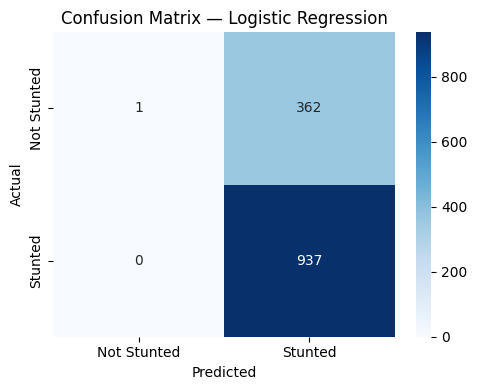

In [8]:
# ── Cell 6: Confusion matrix plot ────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Stunted', 'Stunted'],
            yticklabels=['Not Stunted', 'Stunted'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(r"F:\FinalYr Project\nutrisense\outputs\figures\confusion_matrix_lr.png", dpi=150)
plt.show()

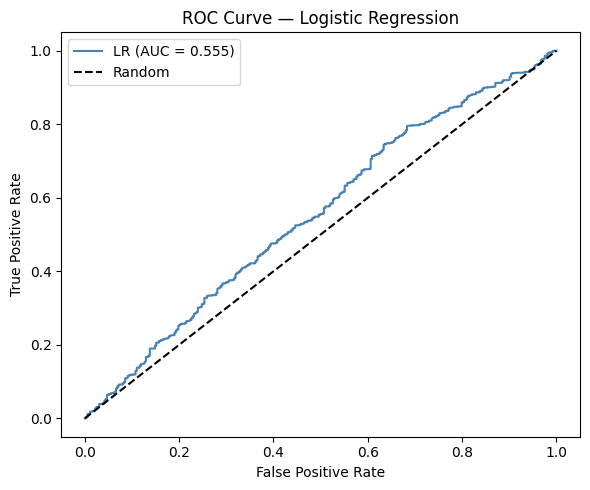

In [9]:
# ── Cell 7: ROC Curve ────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'LR (AUC = {auc:.3f})', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend(); plt.tight_layout()
plt.savefig(r"F:\FinalYr Project\nutrisense\outputs\figures\roc_curve_lr.png", dpi=150)
plt.show()